## Task: Data Loading and exploring...

First ideas and functions

In [42]:
import pandas as pd
import numpy as np

In [43]:
url = 'https://srhdpeuwpubsa.blob.core.windows.net/whdh/COVID/WHO-COVID-19-global-data.csv'
df_original = pd.read_csv(url)
df = df_original.copy()
# Define column names
# names = ['Date_reported', 'Country_code', 'Country', 'WHO_region', 'New_cases', 'Cumulative_cases', 'New_deaths', 'Cumulative_deaths']
# df = pd.read_csv(url, names=names)

In [44]:
df.head()

,Date_reported,Country_code,Country,WHO_region,New_cases,Cumulative_cases,New_deaths,Cumulative_deaths
0,2020-01-05,AM,Armenia,EURO,NaN,0,NaN,0
1,2020-01-12,AM,Armenia,EURO,NaN,0,NaN,0
2,2020-01-19,AM,Armenia,EURO,NaN,0,NaN,0
3,2020-01-26,AM,Armenia,EURO,NaN,0,NaN,0
4,2020-02-02,AM,Armenia,EURO,NaN,0,NaN,0


In [45]:
df.shape

(79200, 8)

In [46]:
df.dtypes

Date_reported         object
Country_code          object
Country               object
WHO_region            object
New_cases            float64
Cumulative_cases       int64
New_deaths           float64
Cumulative_deaths      int64
dtype: object

In [47]:
a = df["Country"].nunique()
b = df["WHO_region"].nunique()
print(a)
print(b)

240
7


In [48]:
df["Country"].value_counts()

Country
Armenia                                330
Afghanistan                            330
Aruba                                  330
Anguilla                               330
Albania                                330
                                      ... 
Saint Vincent and the Grenadines       330
Venezuela (Bolivarian Republic of)     330
United States Virgin Islands           330
International conveyance (Kiribati)    330
International commercial vessel        330
Name: count, Length: 240, dtype: int64

In [49]:
df["WHO_region"].value_counts()

WHO_region
EURO     18150
AMRO     15510
AFRO     15510
WPRO     11220
EMRO      7260
SEARO     3630
OTHER     1980
Name: count, dtype: int64

In [50]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 79200 entries, 0 to 79199
Data columns (total 8 columns):
 #   Column             Non-Null Count  Dtype  
---  ------             --------------  -----  
 0   Date_reported      79200 non-null  object 
 1   Country_code       78870 non-null  object 
 2   Country            79200 non-null  object 
 3   WHO_region         73260 non-null  object 
 4   New_cases          51584 non-null  float64
 5   Cumulative_cases   79200 non-null  int64  
 6   New_deaths         36847 non-null  float64
 7   Cumulative_deaths  79200 non-null  int64  
dtypes: float64(2), int64(2), object(4)
memory usage: 4.8+ MB


## Task 1: Weekly new cases and deaths

Here you need to create a plot with **new confirmed cases** and **deaths** for a country of your choice using the data till August 1st 2024. 

Your steps can be as follows:
- Filter the data to only include entries before August 1st 2024.
- Choose any country given in the dataset and extract corresponding entries.
- Create a plot of **new cases** with filled area under curve (use ```plt.fill_between``` function).
- Create the same plot for **new deaths**.

In [51]:
df.head()

,Date_reported,Country_code,Country,WHO_region,New_cases,Cumulative_cases,New_deaths,Cumulative_deaths
0,2020-01-05,AM,Armenia,EURO,NaN,0,NaN,0
1,2020-01-12,AM,Armenia,EURO,NaN,0,NaN,0
2,2020-01-19,AM,Armenia,EURO,NaN,0,NaN,0
3,2020-01-26,AM,Armenia,EURO,NaN,0,NaN,0
4,2020-02-02,AM,Armenia,EURO,NaN,0,NaN,0


In [52]:
df["Date_reported"] = pd.to_datetime(df["Date_reported"])

df_filtered = df[
    (df["Date_reported"] < "2024-08-01") &
    (df["Country"] == "Germany")
]

dates = df_filtered["Date_reported"]
new_cases = df_filtered["New_cases"]
new_deaths = df_filtered["New_deaths"]


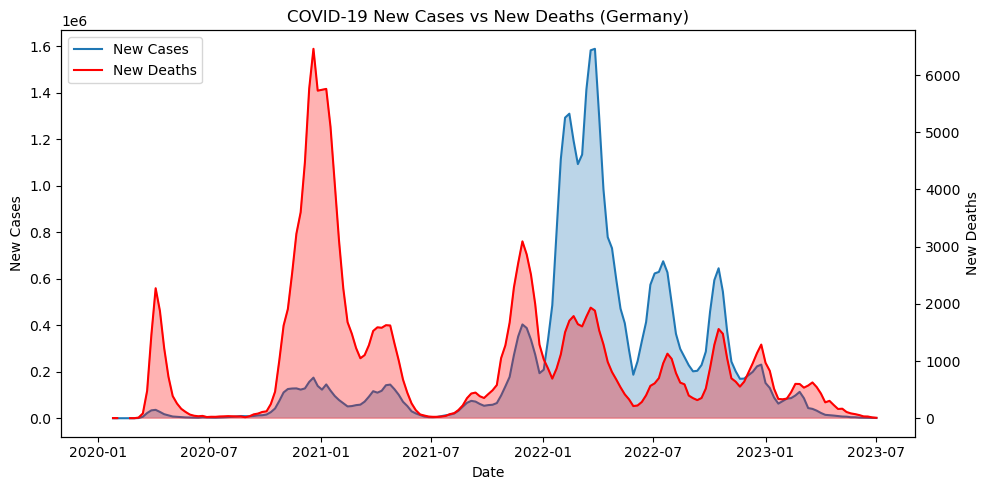

In [53]:
import matplotlib.pyplot as plt

fig, ax1 = plt.subplots(figsize=(10, 5))

# LEFT axis → New Cases
ax1.plot(dates, new_cases, label="New Cases")
ax1.fill_between(dates, new_cases, alpha=0.3)
ax1.set_xlabel("Date")
ax1.set_ylabel("New Cases")

# RIGHT axis → New Deaths
ax2 = ax1.twinx()

ax2.plot(dates, new_deaths, label="New Deaths", color="red")
ax2.fill_between(dates, new_deaths, alpha=0.3, color="red")
ax2.set_ylabel("New Deaths")

# Title
plt.title("COVID-19 New Cases vs New Deaths (Germany)")

# Rotate dates
plt.xticks(rotation=45)

# Layout
fig.tight_layout()

lines_1, labels_1 = ax1.get_legend_handles_labels()
lines_2, labels_2 = ax2.get_legend_handles_labels()

ax1.legend(lines_1 + lines_2, labels_1 + labels_2, loc="upper left")

plt.show()


In [54]:
"""
First Idea of plotting new cases/ new deaths in two different plots using the same code but just changing the column name and color
Here is just the code for new deaths:

plt.plot(dates, new_deaths, label="New Deaths", color="red")
plt.fill_between(dates, new_deaths, alpha=0.3)

plt.xlabel("Date")
plt.ylabel("Number of Deaths")
plt.title("COVID-19 New Deaths in Germany")
plt.legend()

plt.xticks(rotation=45)
plt.tight_layout()

plt.show()

"""

'\nFirst Idea of plotting new cases/ new deaths in two different plots using the same code but just changing the column name and color\nHere is just the code for new deaths:\n\nplt.plot(dates, new_deaths, label="New Deaths", color="red")\nplt.fill_between(dates, new_deaths, alpha=0.3)\n\nplt.xlabel("Date")\nplt.ylabel("Number of Deaths")\nplt.title("COVID-19 New Deaths in Germany")\nplt.legend()\n\nplt.xticks(rotation=45)\nplt.tight_layout()\n\nplt.show()\n\n'

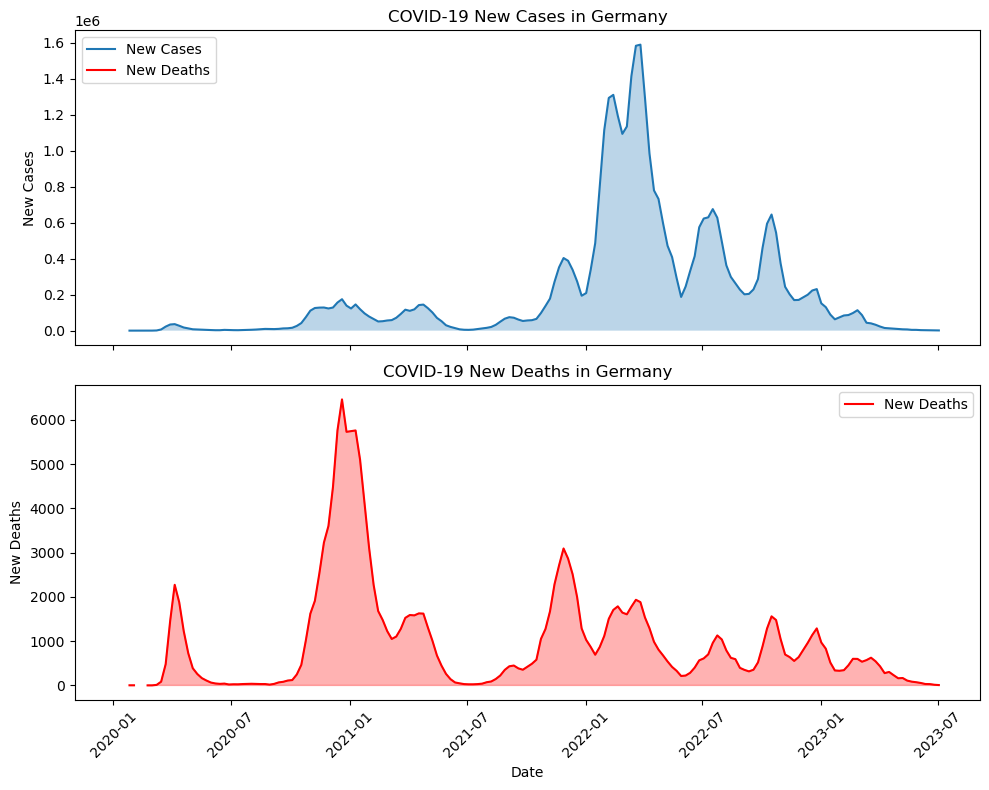

In [55]:
fig, (ax1, ax2) = plt.subplots(2, 1, figsize=(10, 8), sharex=True)

# 🔹 Top plot → New Cases
ax1.plot(dates, new_cases, label="New Cases")
ax1.fill_between(dates, new_cases, alpha=0.3)
ax1.set_ylabel("New Cases")
ax1.set_title("COVID-19 New Cases in Germany")
ax1.legend()

# 🔹 Bottom plot → New Deaths
ax2.plot(dates, new_deaths, label="New Deaths", color="red")
ax2.fill_between(dates, new_deaths, alpha=0.3, color="red")
ax2.set_ylabel("New Deaths")
ax2.set_title("COVID-19 New Deaths in Germany")
ax2.legend()

# X-axis (only needed once because shared)
ax2.set_xlabel("Date")

# Rotate dates
plt.xticks(rotation=45)

# Layout
plt.tight_layout()
lines_1, labels_1 = ax1.get_legend_handles_labels()
lines_2, labels_2 = ax2.get_legend_handles_labels()

ax1.legend(lines_1 + lines_2, labels_1 + labels_2, loc="upper left")

plt.show()

## Task 2: Cumulative cases and deaths

Create the same plot as in Task 1 but for cumulative cases and deaths.

In [56]:
dates = df_filtered["Date_reported"]
cumulative_cases = df_filtered["Cumulative_cases"]
cumulative_deaths = df_filtered["Cumulative_deaths"]

df_filtered[["Cumulative_cases", "Cumulative_deaths"]].head()

,Cumulative_cases,Cumulative_deaths
19486,1,3
19487,1,3
19488,1,3
19489,2,6
19490,11,9


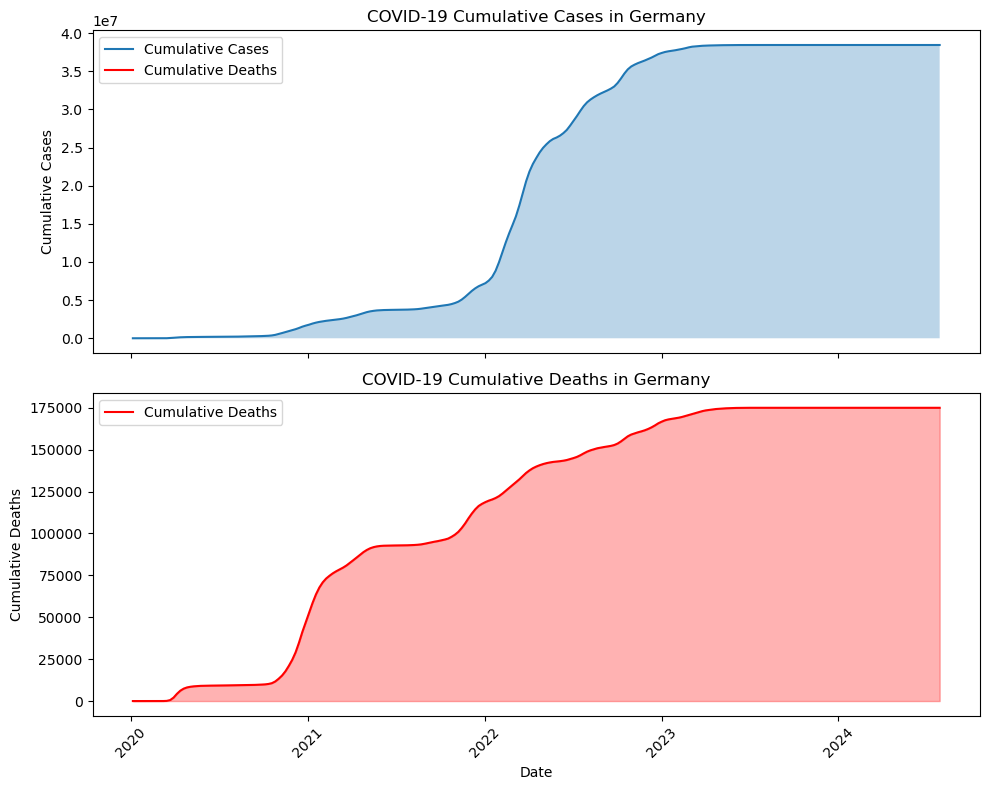

In [57]:
fig, (ax1, ax2) = plt.subplots(2, 1, figsize=(10, 8), sharex=True)

# 🔹 Top plot → Cumulative Cases
ax1.plot(dates, cumulative_cases, label="Cumulative Cases")
ax1.fill_between(dates, cumulative_cases, alpha=0.3)
ax1.set_ylabel("Cumulative Cases")
ax1.set_title("COVID-19 Cumulative Cases in Germany")
ax1.legend()

# 🔹 Bottom plot → Cumulative Deaths
ax2.plot(dates, cumulative_deaths, label="Cumulative Deaths", color="red")
ax2.fill_between(dates, cumulative_deaths, alpha=0.3, color="red")
ax2.set_ylabel("Cumulative Deaths")
ax2.set_title("COVID-19 Cumulative Deaths in Germany")
ax2.legend()

# X-axis (only needed once because shared)
ax2.set_xlabel("Date")

# Rotate dates
plt.xticks(rotation=45)

# Layout
plt.tight_layout()
lines_1, labels_1 = ax1.get_legend_handles_labels()
lines_2, labels_2 = ax2.get_legend_handles_labels()

ax1.legend(lines_1 + lines_2, labels_1 + labels_2, loc="upper left")

plt.show()


## Task 3: Confirmed cases by world region

The WHO dataset includes a column specifying the **WHO region** to which each country belongs. Your task is to calculate how much each WHO region contributes to the total number of weekly confirmed Covid-19 cases worldwide.

You can follows this plan:
- Group the data by WHO regions.
- Ensure that the timestamps (days when the cases are reported) are the same for each country and region, and sum the cases per region for each timestamp.
- Stack ```fill_between``` plots for each region on top of each other to create a figure of total world cases with colors indicating the region (see figure examples below).

In [81]:
df_grouped = df.groupby(["Date_reported", "WHO_region"])["New_cases"].sum()

df_grouped.head()


Date_reported  WHO_region
2020-01-05     AFRO          0.0
               AMRO          0.0
               EMRO          0.0
               EURO          1.0
               OTHER         0.0
Name: New_cases, dtype: float64

In [ ]:
from pandas import pivot_table

df_grouped = (
    df.groupby(["Date_reported", "WHO_region"])["New_cases"]
    .sum()
)

df_grouped = df_grouped.unstack(level="WHO_region")
df_grouped.fillna(0, inplace=True)

# Alternative: directly use pivot_table - but it did not work for me - try to fix it later
# pivot_table(df_grouped, index="Date_reported", columns="WHO_region", values="New_cases")
# df_grouped.pivot_table(index="Date_reported", columns="WHO_region", values="New_cases")



WHO_region,AFRO,AMRO,EMRO,EURO,OTHER,SEARO,WPRO
Date_reported,,,,,,,
2020-01-05,0.0,0.0,0.0,1.0,0.0,0.0,1.0
2020-01-12,0.0,0.0,0.0,1.0,0.0,0.0,44.0
2020-01-19,0.0,0.0,0.0,2.0,0.0,2.0,82.0
2020-01-26,0.0,8.0,0.0,5.0,0.0,4.0,1878.0
2020-02-02,0.0,5.0,5.0,21.0,0.0,17.0,12482.0


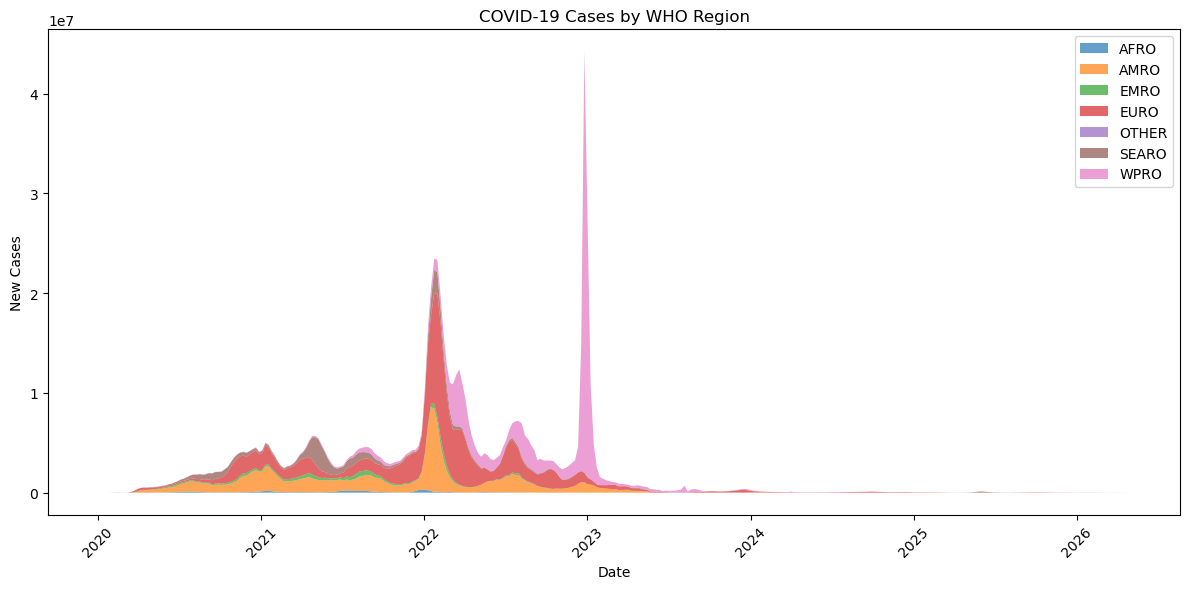

: 

In [ ]:
plt.figure(figsize=(12, 6))

bottom = np.zeros(len(df_grouped))

for region in df_grouped.columns:
    values = df_grouped[region].to_numpy()
    top = bottom + values
    
    plt.fill_between(df_grouped.index, bottom, top, label=region, alpha=0.7)
    
    bottom = top.copy()

plt.xlabel("Date")
plt.ylabel("New Cases")
plt.title("COVID-19 Cases by WHO Region")
plt.legend(loc="upper right")
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()